In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
csv_path = r"antidice_PointGoal1_seed0_20260206_184622.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (101, 25)

First few rows:
   iteration  elapsed_time                                      cost_loss  \
0          0   1150.238256   tf.Tensor(1.253416, shape=(), dtype=float32)   
1      10000   1846.969199  tf.Tensor(1.2538608, shape=(), dtype=float32)   
2      20000   2510.554248  tf.Tensor(1.2350026, shape=(), dtype=float32)   
3      30000   3179.306716  tf.Tensor(1.2578113, shape=(), dtype=float32)   
4      40000   3883.079270   tf.Tensor(1.220799, shape=(), dtype=float32)   

                                         nu_loss  \
0     tf.Tensor(8.1162, shape=(), dtype=float32)   
1   tf.Tensor(6.513408, shape=(), dtype=float32)   
2  tf.Tensor(6.5779214, shape=(), dtype=float32)   
3  tf.Tensor(6.4591837, shape=(), dtype=float32)   
4  tf.Tensor(6.5124745, shape=(), dtype=float32)   

                                       actor_loss  \
0    tf.Tensor(26.42466, shape=(), dtype=float32)   
1  tf.Tensor(-14.130053, shape=(), dtype=float32)   
2  tf.Tensor(-14.109621

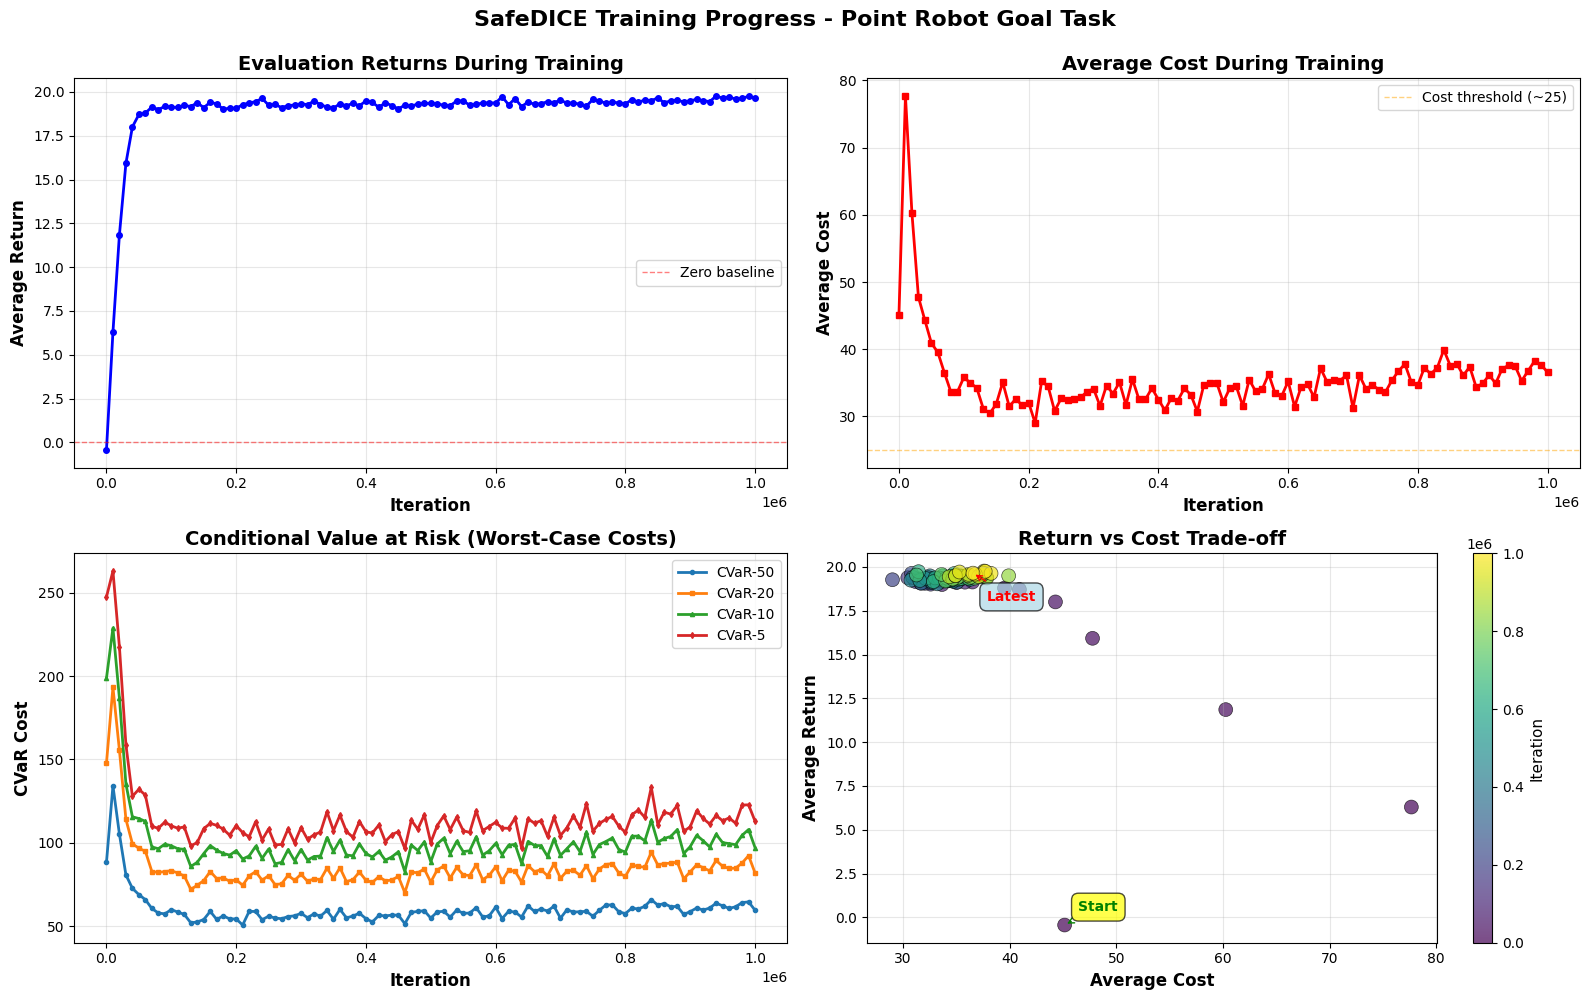


TRAINING SUMMARY STATISTICS

Total iterations logged: 101
Total elapsed time: 68426.79 seconds (19.01 hours)

📊 EVALUATION RETURNS:
   Initial: -0.4364
   Final:   19.6450
   Best:    19.7655 (at iteration 940000)
   Worst:   -0.4364 (at iteration 0)

⚠️  AVERAGE COSTS:
   Initial: 45.1520
   Final:   36.5520
   Lowest:  29.0080 (at iteration 210000)
   Highest: 77.6720 (at iteration 10000)

🎯 CVAR METRICS (Final):
   CVaR-50: 59.7000
   CVaR-20: 81.9800
   CVaR-10: 97.1800
   CVaR-5:  113.0000



In [6]:
# Create comprehensive plots for SafeDICE training metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Evaluation Returns over iterations
ax1 = axes[0, 0]
ax1.plot(df['iteration'], df['eval_return'], linewidth=2, color='blue', marker='o', markersize=4)
ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Return', fontsize=12, fontweight='bold')
ax1.set_title('Evaluation Returns During Training', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Zero baseline')
ax1.legend(fontsize=10)

# Plot 2: Average Cost over iterations
ax2 = axes[0, 1]
ax2.plot(df['iteration'], df['eval_cost'], linewidth=2, color='red', marker='s', markersize=4)
ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Cost', fontsize=12, fontweight='bold')
ax2.set_title('Average Cost During Training', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=25, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Cost threshold (~25)')
ax2.legend(fontsize=10)

# Plot 3: CVaR values (risk metrics)
ax3 = axes[1, 0]
ax3.plot(df['iteration'], df['CVar50'], linewidth=2, label='CVaR-50', marker='o', markersize=3)
ax3.plot(df['iteration'], df['CVar20'], linewidth=2, label='CVaR-20', marker='s', markersize=3)
ax3.plot(df['iteration'], df['CVar10'], linewidth=2, label='CVaR-10', marker='^', markersize=3)
ax3.plot(df['iteration'], df['CVar5'], linewidth=2, label='CVaR-5', marker='d', markersize=3)
ax3.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax3.set_ylabel('CVaR Cost', fontsize=12, fontweight='bold')
ax3.set_title('Conditional Value at Risk (Worst-Case Costs)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# Plot 4: Return vs Cost (trade-off visualization)
ax4 = axes[1, 1]
scatter = ax4.scatter(df['eval_cost'], df['eval_return'], c=df['iteration'], cmap='viridis', 
                      s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Average Cost', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Return', fontsize=12, fontweight='bold')
ax4.set_title('Return vs Cost Trade-off', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Iteration', fontsize=11)

# Add annotations for first and last points
ax4.annotate('Start', xy=(df['eval_cost'].iloc[0], df['eval_return'].iloc[0]), 
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, fontweight='bold', color='green',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='green'))

if len(df) > 1:
    ax4.annotate('Latest', xy=(df['eval_cost'].iloc[-1], df['eval_return'].iloc[-1]), 
                 xytext=(10, -20), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='red',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red'))

plt.suptitle('SafeDICE Training Progress - Point Robot Goal Task', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('data_analysis_plots/safedice_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("TRAINING SUMMARY STATISTICS")
print("=" * 80)
print(f"\nTotal iterations logged: {len(df)}")
print(f"Total elapsed time: {df['elapsed_time'].iloc[-1]:.2f} seconds ({df['elapsed_time'].iloc[-1]/3600:.2f} hours)")

print(f"\n📊 EVALUATION RETURNS:")
print(f"   Initial: {df['eval_return'].iloc[0]:.4f}")
print(f"   Final:   {df['eval_return'].iloc[-1]:.4f}")
print(f"   Best:    {df['eval_return'].max():.4f} (at iteration {df.loc[df['eval_return'].idxmax(), 'iteration']:.0f})")
print(f"   Worst:   {df['eval_return'].min():.4f} (at iteration {df.loc[df['eval_return'].idxmin(), 'iteration']:.0f})")

print(f"\n⚠️  AVERAGE COSTS:")
print(f"   Initial: {df['eval_cost'].iloc[0]:.4f}")
print(f"   Final:   {df['eval_cost'].iloc[-1]:.4f}")
print(f"   Lowest:  {df['eval_cost'].min():.4f} (at iteration {df.loc[df['eval_cost'].idxmin(), 'iteration']:.0f})")
print(f"   Highest: {df['eval_cost'].max():.4f} (at iteration {df.loc[df['eval_cost'].idxmax(), 'iteration']:.0f})")

print(f"\n🎯 CVAR METRICS (Final):")
print(f"   CVaR-50: {df['CVar50'].iloc[-1]:.4f}")
print(f"   CVaR-20: {df['CVar20'].iloc[-1]:.4f}")
print(f"   CVaR-10: {df['CVar10'].iloc[-1]:.4f}")
print(f"   CVaR-5:  {df['CVar5'].iloc[-1]:.4f}")

print("\n" + "=" * 80)